In [1]:
from upsetplot import UpSet, from_memberships, from_contents
from matplotlib import pyplot as plt
import pandas as pd
from pathlib import Path
import pysam
import numpy as np
from collections import Counter, defaultdict
import pyranges as pr
import itertools
import subprocess
import seaborn as sns

# Score, filter bam files

In [2]:
!python score_filter_bam.py -h

usage: score_filter_bam.py [-h] [--outdir OUTDIR] inbam

Filter a BAM file to keep only the top scoring alignment for each read.

positional arguments:
  inbam            Path to input BAM file

options:
  -h, --help       show this help message and exit
  --outdir OUTDIR  Optional: path to output directory


In [4]:
!python score_filter_bam.py ../longread_txome/SGNex_MCF7_directcDNA_replicate3_run3_directcDNA_txome.bam --outdir ../longread_files/00_txome/SGNex_MCF7_directcDNA_replicate3_run3

INFO:root:Reading ../longread_txome/SGNex_MCF7_directcDNA_replicate3_run3_directcDNA_txome.bam and filtering top alignments...
[E::idx_find_and_load] Could not retrieve index file for '../longread_txome/SGNex_MCF7_directcDNA_replicate3_run3_directcDNA_txome.bam'
INFO:root:Finished filtering top alignments in 34.46 seconds.
INFO:root:Writing top alignments to /netapp/LOG-G4/jfaybishenko/bulk_te_bench/analysis/longread_files/00_txome/SGNex_MCF7_directcDNA_replicate3_run3/tmptfnpdfik.bam and unique-mapping read IDs to ../longread_files/00_txome/SGNex_MCF7_directcDNA_replicate3_run3/SGNex_MCF7_directcDNA_replicate3_run3_directcDNA_txome_unique_reads.txt...
[E::idx_find_and_load] Could not retrieve index file for '../longread_txome/SGNex_MCF7_directcDNA_replicate3_run3_directcDNA_txome.bam'
INFO:root:Finished writing top alignments in 29.64 seconds.
INFO:root:Sorting /netapp/LOG-G4/jfaybishenko/bulk_te_bench/analysis/longread_files/00_txome/SGNex_MCF7_directcDNA_replicate3_run3/tmptfnpdfik.

In [20]:
!python score_filter_bam.py ../longread_txome/SGNex_MCF7_directcDNA_replicate4_run2_directcDNA_txome.bam --outdir ../longread_files/00_txome/SGNex_MCF7_directcDNA_replicate4_run2

INFO:root:Reading ../longread_txome/SGNex_MCF7_directcDNA_replicate4_run2_directcDNA_txome.bam and filtering top alignments...
[E::idx_find_and_load] Could not retrieve index file for '../longread_txome/SGNex_MCF7_directcDNA_replicate4_run2_directcDNA_txome.bam'
INFO:root:Finished filtering top alignments in 98.26 seconds.
INFO:root:Writing top alignments to /netapp/LOG-G4/jfaybishenko/bulk_te_bench/analysis/longread_files/00_txome/SGNex_MCF7_directcDNA_replicate4_run2/tmpf_bvuj37.bam and unique-mapping read IDs to ../longread_files/00_txome/SGNex_MCF7_directcDNA_replicate4_run2/SGNex_MCF7_directcDNA_replicate4_run2_directcDNA_txome_unique_reads.txt...
[E::idx_find_and_load] Could not retrieve index file for '../longread_txome/SGNex_MCF7_directcDNA_replicate4_run2_directcDNA_txome.bam'
INFO:root:Finished writing top alignments in 72.04 seconds.
INFO:root:Sorting /netapp/LOG-G4/jfaybishenko/bulk_te_bench/analysis/longread_files/00_txome/SGNex_MCF7_directcDNA_replicate4_run2/tmpf_bvuj37.

# Run bedtools 

In [85]:
def intersect(file_path: str, family: str):
    """
    Runs bedtools intersect on a bam file with the gtf categories for an L1 family
    @param file_path: path to the bam file
    @param family: L1 family
    @return: True if successful
    """

    categories = [
        f"{family}",
        f"full_intergenic_{family}",
        f"full_intronic_{family}",
        f"truncate_intergenic_{family}",
        f"truncate_intronic_{family}",
    ]

    prefix = "/".join(file_path.split("/")[:-1])

    for cat in categories:
        output_file = f"{prefix}/{cat}.bed"
        gtf_file = "../data/gtf_categories/" + cat + ".gtf"

        # get list of transcript IDs from gtf file
        L1_loci = list(pr.read_gtf(gtf_file).df["transcript_id"])
        reads = []

        # iterate over bam file
        with pysam.AlignmentFile(file_path, "rb") as bam:
            for aln in bam:
                # get transctipt ID
                transcript_id = aln.reference_name
                # check if transcript ID is in list
                if transcript_id in L1_loci:
                    # write output of reads to bed file
                    reads.append(
                        [
                            aln.reference_name,
                            aln.reference_start,
                            aln.reference_end,
                            aln.query_name,
                            aln.is_reverse,
                        ]
                    )

        # write output of reads to bed file
        with open(output_file, "w") as f:
            for read in reads:
                f.write("\t".join(map(str, read)) + "\n")

    return True

In [86]:
# Get the L1 families
L1_families = ["L1HS", "L1PA2", "L1PA3", "L1PA6"]

bamfiles = [
    "../longread_files/00_txome/SGNex_MCF7_directcDNA_replicate3_run3/SGNex_MCF7_directcDNA_replicate3_run3_directcDNA_txome_top.bam",
    "../longread_files/00_txome/SGNex_MCF7_directcDNA_replicate4_run2/SGNex_MCF7_directcDNA_replicate4_run2_directcDNA_txome_top.bam",
]

for bam in bamfiles:
    print(f"*****Processing {bam}*****")
    for i, family in enumerate(L1_families):
        print(f"{i}: processing {family}")
        last_file = intersect(bam, family)

*****Processing ../longread_files/00_txome/SGNex_MCF7_directcDNA_replicate3_run3/SGNex_MCF7_directcDNA_replicate3_run3_directcDNA_txome_top.bam*****
0: processing L1HS
1: processing L1PA2
2: processing L1PA3
3: processing L1PA6
*****Processing ../longread_files/00_txome/SGNex_MCF7_directcDNA_replicate4_run2/SGNex_MCF7_directcDNA_replicate4_run2_directcDNA_txome_top.bam*****
0: processing L1HS
1: processing L1PA2
2: processing L1PA3
3: processing L1PA6


## Make upset_plots

In [87]:
def read_data(
    base_path: str,
    categories: list,
    seperate_unique_multi: bool = False,
    reads_path=None,
) -> pd.DataFrame():
    """
    reads bedfiles for categories in path and return dataframe compatible with upsetplot
    @param base_path: str path to bedfiles
    @param categories: str list of categories to read
    @return: dataframe compatible with upsetplot
    """

    if seperate_unique_multi:
        with open(reads_path, "r") as f:
            unique_reads = f.read().split()

    ids = {}
    # get list of read_ids for each sample
    for cat in categories:

        # if bed file is empty
        if Path(f"{base_path}/{cat}.bed").stat().st_size == 0:
            continue

        if not seperate_unique_multi:
            ids[cat] = (
                pd.read_csv(f"{base_path}/{cat}.bed", sep="\t", header=None)[3]
                .drop_duplicates()
                .to_list()
            )
        else:
            # iterate through reads and determine if unique or not
            ids[cat + "_unique"] = []
            ids[cat + "_multi"] = []
            for read in (
                pd.read_csv(f"{base_path}/{cat}.bed", sep="\t", header=None)[3]
                .drop_duplicates()
                .to_list()
            ):
                if read in unique_reads:
                    ids[cat + "_unique"].append(read)
                else:
                    ids[cat + "_multi"].append(read)

    return from_contents(ids)

In [88]:
bamfiles = [
    "../longread_files/00_txome/SGNex_MCF7_directcDNA_replicate3_run3/SGNex_MCF7_directcDNA_replicate3_run3_directcDNA_txome_top.bam",
    "../longread_files/00_txome/SGNex_MCF7_directcDNA_replicate4_run2/SGNex_MCF7_directcDNA_replicate4_run2_directcDNA_txome_top.bam",
]

L1_families = ["L1HS", "L1PA2", "L1PA3", "L1PA6"]
regions = [
    "full_intergenic",
    "full_intronic",
    "truncate_intergenic",
    "truncate_intronic",
]

all_dirs = [
    (str(Path(bam).parent), bam.replace("_top.bam", "_unique_reads.txt"))
    for bam in bamfiles
]


def make_a_plot(
    path: str, categories: list, seperate_unique_multi: bool = False, reads_path=None
):
    """
    uses upsetplot to make a plot of the data
    @param path: str path to bedfiles
    @param categories: str list of categories to read
    @param seperate_unique_multi: bool if True, will seperate unique and multi reads
    @param reads_path: str path to file with unique reads, only used if seperate_unique_multi is True
    """
    data = read_data(path, categories, seperate_unique_multi, reads_path)
    UpSet(data, subset_size="auto", show_counts=True, sort_categories_by="input").plot()
    plt.suptitle(path)
    plt.show()
    plt.clf()

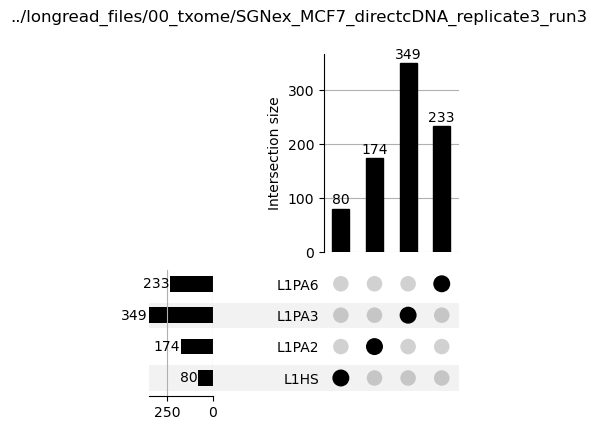

<Figure size 640x480 with 0 Axes>

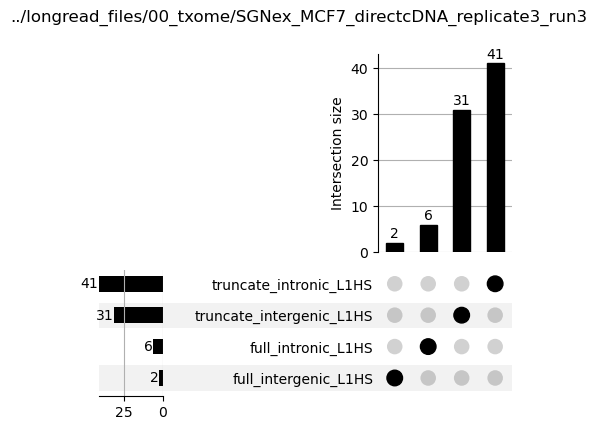

<Figure size 640x480 with 0 Axes>

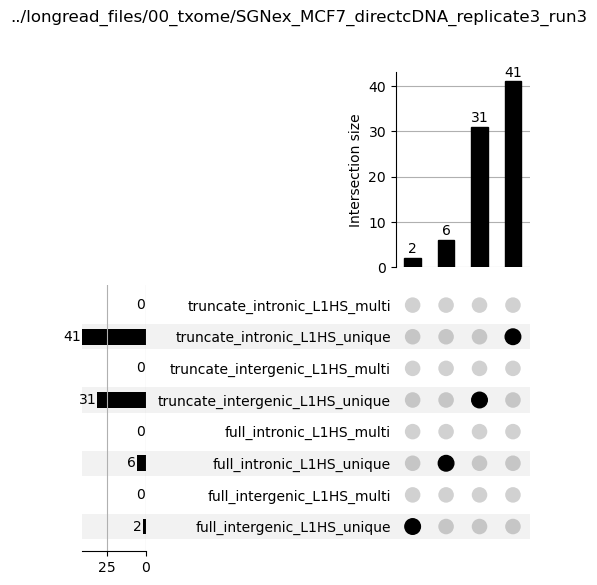

<Figure size 640x480 with 0 Axes>

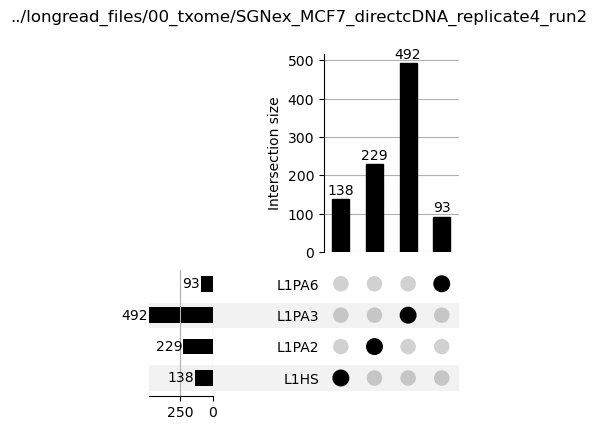

<Figure size 640x480 with 0 Axes>

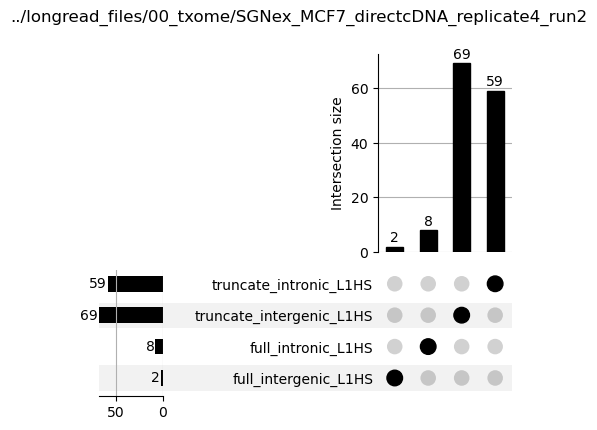

<Figure size 640x480 with 0 Axes>

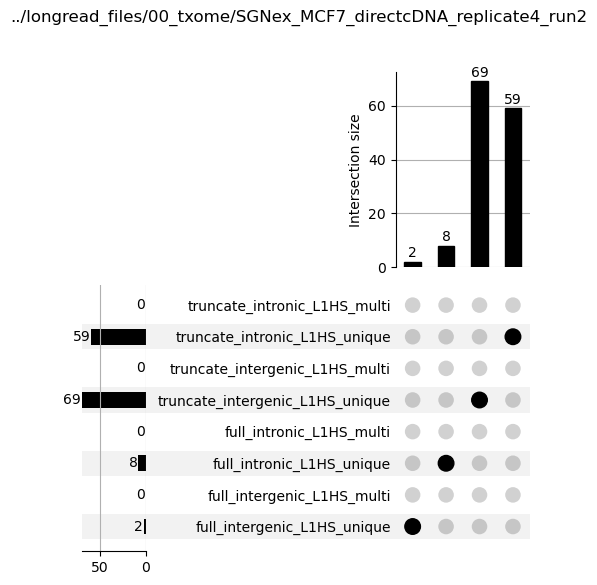

<Figure size 640x480 with 0 Axes>

In [89]:
for path_tuple in all_dirs:
    dirpath = path_tuple[0]
    readspath = path_tuple[1]
    make_a_plot(dirpath, categories=L1_families)

    make_a_plot(dirpath, categories=[cat + "_L1HS" for cat in regions])
    make_a_plot(
        dirpath,
        categories=[cat + "_L1HS" for cat in regions],
        seperate_unique_multi=True,
        reads_path=readspath,
    )

# Confusion matrix

for a pair of bams (txome and genome aligned):

1. get read_ids from both bams that map to L1, union
2. get alignments from both bams from read_ids
3. assign each read_id to one or more categories for each bam
4. ? remove reads that belong to multiple categories within a bam

                         full_intergenic_L1HS full_intronic_L1HS  \
full_intergenic_L1HS                        1                  1   
full_intronic_L1HS                          0                  4   
truncate_intergenic_L1HS                    6                 12   
truncate_intronic_L1HS                      7                 11   

                         truncate_intergenic_L1HS truncate_intronic_L1HS  
full_intergenic_L1HS                            0                      0  
full_intronic_L1HS                              1                      0  
truncate_intergenic_L1HS                        5                      5  
truncate_intronic_L1HS                          6                     10  


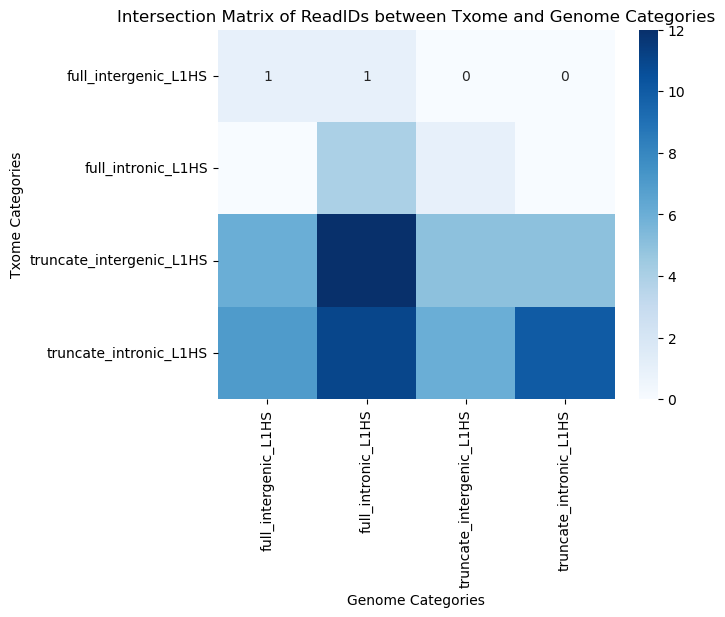

In [92]:
categories = [
    "full_intergenic_L1HS",
    "full_intronic_L1HS",
    "truncate_intergenic_L1HS",
    "truncate_intronic_L1HS",
]

readIDs_per_category = {
    "txome": {cat: set() for cat in categories},
    "genome": {cat: set() for cat in categories},
}

mapping_per_category = {
    "txome": "../longread_files/00_txome/SGNex_MCF7_directcDNA_replicate3_run3",
    "genome": "../longread_files/SGNex_MCF7_directcDNA_replicate3_run3",
}


for cat in categories:
    for type in ["txome", "genome"]:
        readIDs_per_category[type][cat] = set(
            pd.read_csv(
                f"{mapping_per_category[type]}/{cat}.bed", sep="\t", header=None
            )[3].drop_duplicates()
        )

# Initialize a DataFrame to store intersection counts
intersection_matrix = pd.DataFrame(index=categories, columns=categories)

# Calculate intersections between all pairs of categories
for cat1 in categories:
    for cat2 in categories:
        intersection_count = len(
            readIDs_per_category["txome"][cat1].intersection(
                readIDs_per_category["genome"][cat2]
            )
        )
        intersection_matrix.loc[cat1, cat2] = intersection_count


sns.heatmap(intersection_matrix.astype(int), annot=True, fmt="d", cmap="Blues")
plt.title("Intersection Matrix of ReadIDs between Txome and Genome Categories")
plt.xlabel("Genome Categories")
plt.ylabel("Txome Categories")
plt.show()

In [93]:
intersection_matrix

,full_intergenic_L1HS,full_intronic_L1HS,truncate_intergenic_L1HS,truncate_intronic_L1HS
full_intergenic_L1HS,1,1,0,0
full_intronic_L1HS,0,4,1,0
truncate_intergenic_L1HS,6,12,5,5
truncate_intronic_L1HS,7,11,6,10
